# CORDEX Future Frequency (Projected Severe Rainfall Events)

This notebook estimates **projected changes in severe rainfall event frequency** using CORDEX daily precipitation output.

**Method continuity with PRISM notebooks:**
- Uses a fixed extreme-event definition (daily precipitation ≥ 3.0 inches ≈ 76.2 mm)
- Counts threshold-exceedance days (frequency), not storm intensity
- Compares frequency across two fixed future windows (early vs late) to reduce interannual noise

**Outputs:**
- Gridded event-frequency counts for each future window
- Gridded difference map (late minus early)
- Saved NetCDF outputs + a saved map image to `outputs/`


## Interpretation Notes

- This step computes **how often** threshold-exceedance days occur in each future window.
- The output is a **frequency stress signal** (event-days per window) derived directly from model grids.
- PRISM outputs in earlier notebooks are usually place-based (e.g., county totals). CORDEX outputs here are **gridded**.


In [1]:
# ----------------------------------
# Repo-aware path setup (REQUIRED)
# ----------------------------------
import sys
from pathlib import Path
import pandas as pd

# Resolve repository root (notebooks/ is one level down)
REPO_ROOT = Path("..").resolve()

# Ensure src/ is importable (future-proofing)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Core repo directories
DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
DATA_SAMPLE_DIR = DATA_DIR / "sample"

OUTPUTS_DIR = REPO_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
MAPS_DIR = OUTPUTS_DIR / "maps"

DOCS_DIR = REPO_ROOT / "docs"
SAMPLE_DIR = REPO_ROOT / "sample_data"

# Ensure output directories exist
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Tables dir:", TABLES_DIR)


Repo root: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework
Tables dir: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables


In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Ensure additional expected dirs exist
RAW_DIR.mkdir(parents=True, exist_ok=True)
DATA_SAMPLE_DIR.mkdir(parents=True, exist_ok=True)
MAPS_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# -----------------------------
# USER CONFIGURATION
        # -----------------------------

# Real CORDEX NetCDF filename (place in data/raw/)
CORDEX_FILENAME = Path("../data/raw/prec.csv")
CORDEX_PATH = RAW_DIR / CORDEX_FILENAME

# Sample CORDEX NetCDF (this notebook can generate it)
SAMPLE_CORDEX_FILENAME = "cordex_daily_precip_sample.nc"
SAMPLE_CORDEX_PATH = DATA_SAMPLE_DIR / SAMPLE_CORDEX_FILENAME

# Variable name expected in the NetCDF
# If not found, the notebook will auto-detect the first data_var.
PRECIP_VAR = "prec"

# Extreme rainfall threshold in millimeters (3 inches ≈ 76.2 mm)
EXTREME_THRESHOLD_MM = 76.2

# Spatial subset (lat/lon bounding box)
LAT_SLICE = (33.8, 37.0)
LON_SLICE = (-84.7, -75.4)

# Future windows (adjust as needed to match your dataset)
EARLY_START = "2021-01-01"
EARLY_END   = "2050-12-31"
LATE_START  = "2051-01-01"
LATE_END    = "2080-12-31"

# Output names
MODEL_LABEL = "sample_or_user_model"
OUT_EARLY_NETCDF = TABLES_DIR / "cordex_future_extreme_freq_early.nc"
OUT_LATE_NETCDF = TABLES_DIR / "cordex_future_extreme_freq_late.nc"
OUT_DIFF_NETCDF = TABLES_DIR / "cordex_future_extreme_freq_diff.nc"
OUT_MANIFEST_CSV = TABLES_DIR / "cordex_run_manifest.csv"
OUT_MAP_PNG = MAPS_DIR / "cordex_future_extreme_freq_diff.png"

In [4]:
# -------------------------------------------------
# Create sample CORDEX NetCDF if it doesn't exist
# -------------------------------------------------

if not SAMPLE_CORDEX_PATH.exists():
    print("Creating sample CORDEX NetCDF at:", SAMPLE_CORDEX_PATH)
    rng = np.random.default_rng(42)

    # Time: daily 2021-01-01 to 2080-12-31
    time = np.arange(np.datetime64("2021-01-01"), np.datetime64("2081-01-01"), np.timedelta64(1, "D"))

    # Small grid subset roughly covering your bbox
    lats = np.linspace(32.0, 37.0, 20)
    lons = np.linspace(-84.5, -75.0, 25)

    # Base precip in mm/day (gamma-like) + rare extreme spikes
    base = rng.gamma(shape=2.0, scale=8.0, size=(time.size, lats.size, lons.size)).astype(np.float32)
    spikes = (rng.random(size=base.shape) < 0.004).astype(np.float32)  # ~0.4% days
    base = base + spikes * rng.uniform(80, 140, size=base.shape).astype(np.float32)

    ds_sample = xr.Dataset(
    coords={
        "time": time,
        "lat": lats,
        "lon": lons
    }
)

    ds_sample["prec"] = xr.DataArray(
    base,
    dims=("time", "lat", "lon"),
    coords={"time": time, "lat": lats, "lon": lons},
    name="prec",
)

    # xarray Dataset creation for data var
    ds_sample["prec"].attrs["units"] = "mm"
    ds_sample["prec"].attrs["long_name"] = "synthetic daily precipitation"

    ds_sample.to_netcdf(SAMPLE_CORDEX_PATH)
    print("Sample CORDEX NetCDF created.")
else:
    print("Sample CORDEX NetCDF already exists:", SAMPLE_CORDEX_PATH)

Creating sample CORDEX NetCDF at: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\sample\cordex_daily_precip_sample.nc
Sample CORDEX NetCDF created.


In [5]:
# Select input source (real data preferred, sample as fallback)
if CORDEX_PATH.exists():
    INPUT_PATH = CORDEX_PATH
    print("Using REAL CORDEX file:", INPUT_PATH)
else:
    INPUT_PATH = SAMPLE_CORDEX_PATH
    print("Using SAMPLE CORDEX file:", INPUT_PATH)

Using SAMPLE CORDEX file: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\data\sample\cordex_daily_precip_sample.nc


In [6]:
# Load dataset
ds = xr.open_dataset(INPUT_PATH)
print(ds)

# Select precip variable
if PRECIP_VAR is not None and PRECIP_VAR in ds.data_vars:
    precip = ds[PRECIP_VAR]
else:
    auto_var = list(ds.data_vars.keys())[0]
    print(f"PRECIP_VAR not found; using auto-detected variable: {auto_var}")
    precip = ds[auto_var]

# Basic sanity checks
if "time" not in precip.dims:
    raise ValueError(f"Expected a 'time' dimension; got dims={precip.dims}")
if "lat" not in precip.dims or "lon" not in precip.dims:
    raise ValueError(
        f"Expected 'lat' and 'lon' dimensions; got dims={precip.dims}.\n"
        "If your CORDEX file uses rlat/rlon or x/y, you will need a small adapter step."
    )

print("Selected precip variable:", precip.name)
print("Time range:", str(precip["time"].min().values), "to", str(precip["time"].max().values))
print("Units:", precip.attrs.get("units", "(unknown)"))

<xarray.Dataset> Size: 44MB
Dimensions:  (time: 21915, lat: 20, lon: 25)
Coordinates:
  * time     (time) datetime64[ns] 175kB 2021-01-01 2021-01-02 ... 2080-12-31
  * lat      (lat) float64 160B 32.0 32.26 32.53 32.79 ... 36.47 36.74 37.0
  * lon      (lon) float64 200B -84.5 -84.1 -83.71 -83.31 ... -75.79 -75.4 -75.0
Data variables:
    prec     (time, lat, lon) float32 44MB ...
Selected precip variable: prec
Time range: 2021-01-01T00:00:00.000000000 to 2080-12-31T00:00:00.000000000
Units: mm


In [7]:
# Subset to region
#lat_min, lat_max = LAT_SLICE
#lon_min, lon_max = LON_SLICE

precip_region = precip #precip.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

print("Region subset dims:", precip_region.dims)
print("Region lat range:", float(precip_region["lat"].min()), "to", float(precip_region["lat"].max()))
print("Region lon range:", float(precip_region["lon"].min()), "to", float(precip_region["lon"].max()))

Region subset dims: ('time', 'lat', 'lon')
Region lat range: 32.0 to 37.0
Region lon range: -84.5 to -75.0


In [8]:
# Flag extreme-event days (threshold exceedance)
extreme_flag = precip_region >= EXTREME_THRESHOLD_MM

print("Extreme flag dtype:", extreme_flag.dtype)
print("Extreme threshold (mm):", EXTREME_THRESHOLD_MM)
print("Example exceedance count (all cells, all time):", int(extreme_flag.sum().values))

Extreme flag dtype: bool
Extreme threshold (mm): 76.2
Example exceedance count (all cells, all time): 52014


In [9]:
# Count extreme-event days in early future window
early_counts = extreme_flag.sel(time=slice(EARLY_START, EARLY_END)).sum(dim="time").astype(np.int32)

print("Early window:", EARLY_START, "to", EARLY_END)
print("Early counts stats:")
print("  min:", int(early_counts.min().values))
print("  max:", int(early_counts.max().values))

Early window: 2021-01-01 to 2050-12-31
Early counts stats:
  min: 34
  max: 74


In [10]:
# Count extreme-event days in late future window
late_counts = extreme_flag.sel(time=slice(LATE_START, LATE_END)).sum(dim="time").astype(np.int32)

print("Late window:", LATE_START, "to", LATE_END)
print("Late counts stats:")
print("  min:", int(late_counts.min().values))
print("  max:", int(late_counts.max().values))

Late window: 2051-01-01 to 2080-12-31
Late counts stats:
  min: 33
  max: 73


In [11]:
# Difference: late minus early
freq_diff = (late_counts - early_counts).astype(np.int32)
freq_diff.name = "extreme_event_day_count_diff"

print("Difference stats (late - early):")
print("  min:", int(freq_diff.min().values))
print("  max:", int(freq_diff.max().values))

Difference stats (late - early):
  min: -31
  max: 30


In [12]:
# Save outputs to NetCDF for reproducibility / downstream mapping
early_out = early_counts.rename("extreme_event_day_count_early")
late_out = late_counts.rename("extreme_event_day_count_late")

early_out.to_netcdf(OUT_EARLY_NETCDF)
late_out.to_netcdf(OUT_LATE_NETCDF)
freq_diff.to_netcdf(OUT_DIFF_NETCDF)

print("Saved:")
print(" -", OUT_EARLY_NETCDF)
print(" -", OUT_LATE_NETCDF)
print(" -", OUT_DIFF_NETCDF)

Saved:
 - C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\cordex_future_extreme_freq_early.nc
 - C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\cordex_future_extreme_freq_late.nc
 - C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\cordex_future_extreme_freq_diff.nc


In [13]:
# Save a run manifest (settings used) for transparency / replication
manifest = pd.DataFrame([{
    "cordex_input": str(INPUT_PATH),
    "precip_var": precip.name,
    "threshold_mm": EXTREME_THRESHOLD_MM,
    "lat_slice": str(LAT_SLICE),
    "lon_slice": str(LON_SLICE),
    "early_start": EARLY_START,
    "early_end": EARLY_END,
    "late_start": LATE_START,
    "late_end": LATE_END,
    "out_early_netcdf": str(OUT_EARLY_NETCDF),
    "out_late_netcdf": str(OUT_LATE_NETCDF),
    "out_diff_netcdf": str(OUT_DIFF_NETCDF),
    "out_map_png": str(OUT_MAP_PNG),
    "model_label": MODEL_LABEL,
}])

manifest.to_csv(OUT_MANIFEST_CSV, index=False)
print("Saved manifest:", OUT_MANIFEST_CSV)
manifest

Saved manifest: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\tables\cordex_run_manifest.csv


,cordex_input,precip_var,threshold_mm,lat_slice,lon_slice,early_start,early_end,late_start,late_end,out_early_netcdf,out_late_netcdf,out_diff_netcdf,out_map_png,model_label
0,C:\Users\admin\Documents\GitHub\nonstationary-...,prec,76.2,"(33.8, 37.0)","(-84.7, -75.4)",2021-01-01,2050-12-31,2051-01-01,2080-12-31,C:\Users\admin\Documents\GitHub\nonstationary-...,C:\Users\admin\Documents\GitHub\nonstationary-...,C:\Users\admin\Documents\GitHub\nonstationary-...,C:\Users\admin\Documents\GitHub\nonstationary-...,sample_or_user_model


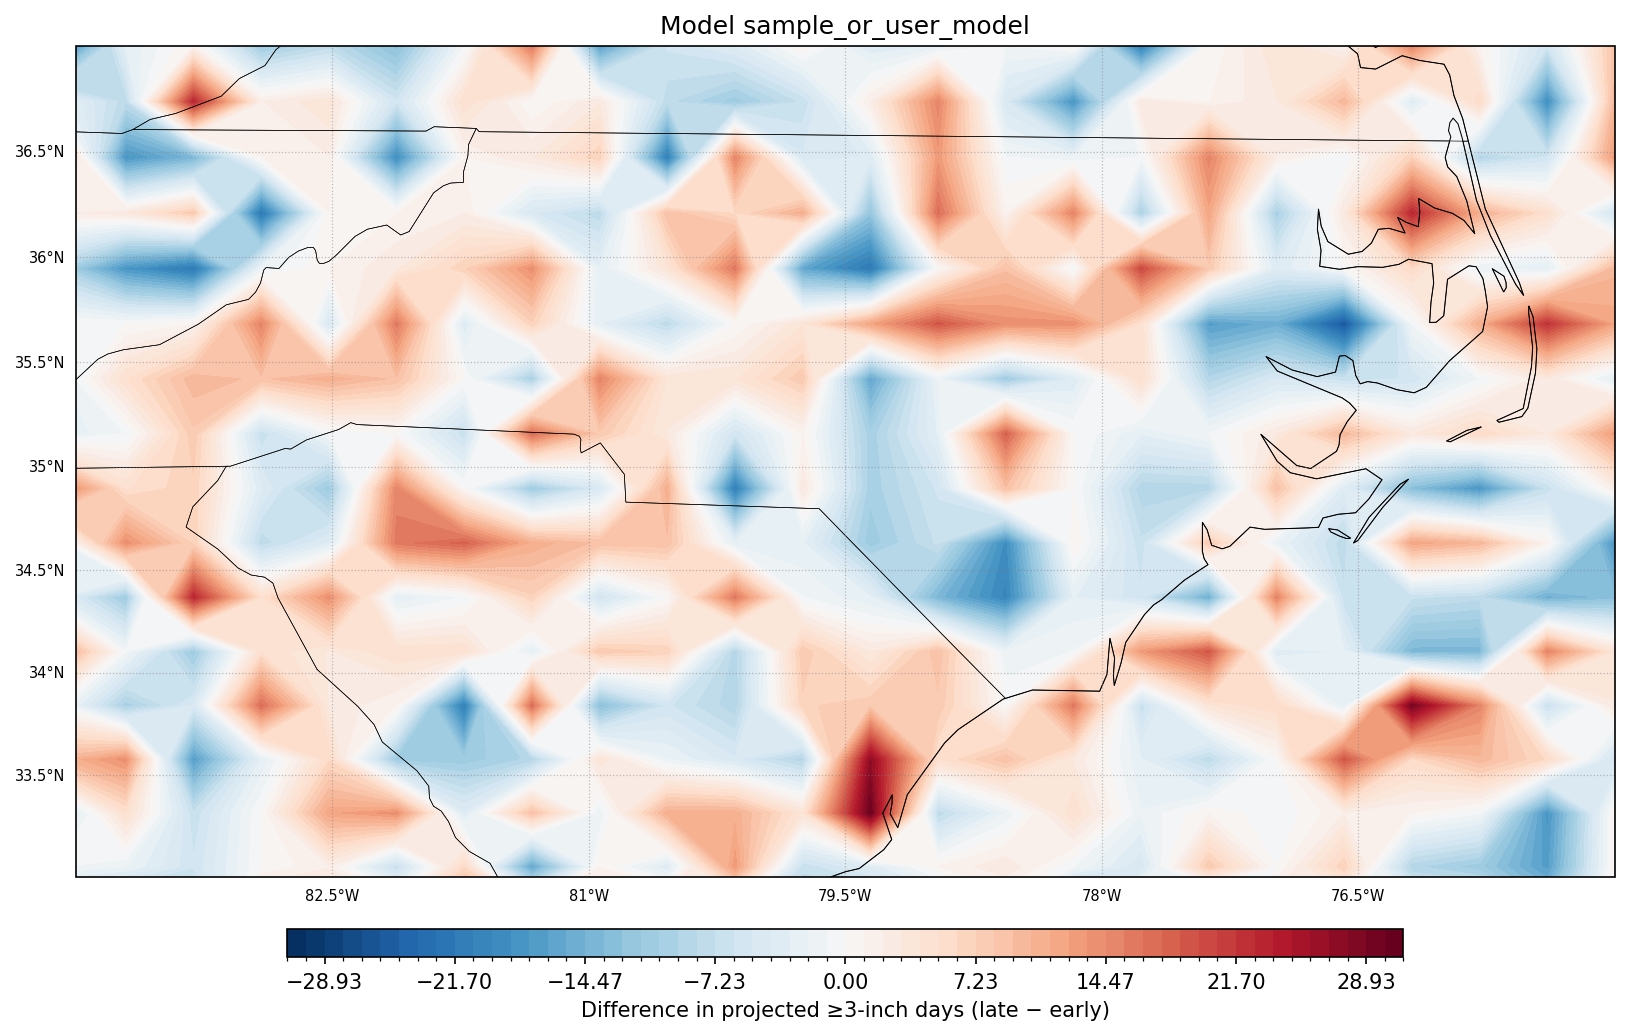

Saved map: C:\Users\admin\Documents\GitHub\nonstationary-flood-risk-framework\outputs\maps\cordex_future_extreme_freq_diff.png
Cartopy used: True


In [15]:
# Plot a map-like view of the difference field
# - Uses Cartopy if installed
# - Falls back to plain matplotlib if not


use_cartopy = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    use_cartopy = True
except Exception:
    use_cartopy = False

# Data bounds (for fallback + sanity)
data_lat_min, data_lat_max = float(freq_diff["lat"].min()), float(freq_diff["lat"].max())
data_lon_min, data_lon_max = float(freq_diff["lon"].min()), float(freq_diff["lon"].max())

# Expand map area for plotting (set for your research interests)
map_lon_min, map_lon_max = -84, -75
map_lat_min, map_lat_max = 33, 37

absmax = float(np.nanmax(np.abs(freq_diff.values)))
if absmax == 0:
    absmax = 1.0

cmap = "RdBu_r"

plt.figure(figsize=(16, 9), dpi=150)

if use_cartopy:
    projection = ccrs.Mercator()
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=projection, frameon=True)

    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.6,
        color="gray",
        alpha=0.5,
        linestyle=":"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.3)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.3)

    ax.set_extent([map_lon_min, map_lon_max, map_lat_min, map_lat_max], crs=data_crs)

    # SIMPLE smoothing: more contour levels
    freq_diff.plot.contourf(
        ax=ax,
        transform=data_crs,
        levels=61,  # <- changed from 21 to 61
        cmap=cmap,
        vmin=-absmax,
        vmax=absmax,
        cbar_kwargs={
            "orientation": "horizontal",
            "shrink": 0.6,
            "pad": 0.05,
            "aspect": 40,
            "label": "Difference in projected ≥3-inch days (late − early)"
        },
    )

    plt.title(f"Model {MODEL_LABEL}")

else:
    ax = plt.gca()
    ax.grid(True, linewidth=0.5, alpha=0.35, linestyle=":")

    plot_lon_min = max(map_lon_min, data_lon_min)
    plot_lon_max = min(map_lon_max, data_lon_max)
    plot_lat_min = max(map_lat_min, data_lat_min)
    plot_lat_max = min(map_lat_max, data_lat_max)

    if plot_lon_min >= plot_lon_max or plot_lat_min >= plot_lat_max:
        plot_lon_min, plot_lon_max = data_lon_min, data_lon_max
        plot_lat_min, plot_lat_max = data_lat_min, data_lat_max

    freq_plot = freq_diff.sel(
        lon=slice(plot_lon_min, plot_lon_max),
        lat=slice(plot_lat_min, plot_lat_max)
    )


    ax.set_xlim(plot_lon_min, plot_lon_max)
    ax.set_ylim(plot_lat_min, plot_lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.title(f"Projected change in ≥3-inch event-days (no-basemap fallback)\nModel: {MODEL_LABEL}")

plt.savefig(OUT_MAP_PNG, bbox_inches="tight")
plt.show()
print("Saved map:", OUT_MAP_PNG)
print("Cartopy used:", use_cartopy)


## Next Steps

This notebook produces gridded future frequency change signals (late minus early) for a fixed extreme-event definition.

These outputs are used in:
- **Notebook 05** (exposure + vulnerability overlays)
- **Notebook 06** (flood probability context)

Users may proceed directly to the next notebook after confirming this step completes successfully.
